# DIverse Counterfactual Explanations (DICE)

In this tutorial, you will learn how to implement a specific type of post-hoc explanations: counterfactual explanations. But what do counterfactual explanations mean?. This kind of explanations is intended to show how the model works by creating hypothetical examples with a prediction with respect to the initial studied instance. In order to do so, we are going to focus on the application of DiCE (original article: Mothilal et al.[[1](https://arxiv.org/pdf/1905.07697.pdf)]) using the framework developped by Mothilal, Sharma and Tan https://github.com/interpretml/DiCE.


## How DiCE generate counterfactual explanations?

The main idea is to generate a set of k counterfactual examples $\{c_1, c_2, ..., c_k\}$ such the decision of the model $f$ given an instance $x$ changes. However, we have to take into account that generating counterfactual examples with a high number of features that have changed is not the ideal approach (Diversity). In the other hand we need to consider counterfactual examples that are close to the original instance $x$ (Proximity) otherwise the explanations will not be useful.

Diversity via Determinantal Point Process:

\begin{gather}
dpp\_diversity  = det(K)
\end{gather}
where $K_{i,j} = \frac{1}{1+dist(c_i,c_j)} $ and $dist(c_i,c_j)$ is a distance metric.

Proximity:
\begin{gather}
Proximity  := -\frac{1}{k} \sum_{i=1}^{k} dist(c_i, x)
\end{gather}

Beyond these main constraints, DiCE allows us to implement constraints that are related to "real world" problems (e.g., an upper bound for some variables)


Based on these definitions DiCE considers the next loss function to be optimized.

\begin{gather}
C(x)  = arg\;min_{c_1, c_2, ..., c_k} \frac{1}{k}\sum_{i=1}^{k} yloss(f(c_i), y) + \frac{\lambda_1}{k} \sum_{i=1}^{k} dist(c_i, x) \\ - \lambda_2 dpp\_diversity(c_1, c_2, ..., c_k)
\end{gather}

where $yloss()$ is a function that measures the distance between $f(c_i)$ and the desired outcome $y$. Both $\lambda_1$ and $\lambda_2$ are hyperparameters that balance the three parts of the loss function.

## Use Case: Heart Disease Prediction

Now we understand how to generate counterfactual explanations, let's focus on a familiar use case in which counterfactual examples are interesting: Heart Disease Prediction.

Heart disease (or coronary artery disease) is one of the leading causes of death worldwide. It results from the narrowing or blockage of coronary arteries, usually due to a build-up of fatty material called plaque. Early detection is crucial to prevent serious cardiac events such as heart attacks.

In this notebook we will create a Heart Disease Prediction Model using the well-known [Cleveland Heart Disease dataset](https://archive.ics.uci.edu/ml/datasets/heart+disease) from the UCI Machine Learning Repository, and then apply DiCE in order to generate counterfactual explanations. These explanations will help clinicians understand which actionable risk factors, if changed, would alter the model's prediction for a given patient.

The use case is organized as follows:
1. We load the Cleveland Heart Disease dataset.
2. We develop a Machine Learning based model for heart disease prediction: the [Random Forest](https://link.springer.com/article/10.1023/A:1010933404324).
3. We apply DiCE to generate counterfactual explanations (https://github.com/interpretml/DiCE).

**Features description:**
- `age`: age in years
- `sex`: sex of the patient (male / female)
- `cp`: chest pain type (typical angina / atypical angina / non-anginal pain / asymptomatic)
- `trestbps`: resting blood pressure in mm Hg
- `chol`: serum cholesterol in mg/dl
- `fbs`: fasting blood sugar > 120 mg/dl (true / false)
- `restecg`: resting ECG results (normal / ST-T wave abnormality / left ventricular hypertrophy)
- `thalach`: maximum heart rate achieved
- `exang`: exercise induced angina (yes / no)
- `oldpeak`: ST depression induced by exercise relative to rest
- `slope`: slope of the peak exercise ST segment (upsloping / flat / downsloping)
- `ca`: number of major vessels colored by fluoroscopy (0–3)
- `thal`: thalassemia type (normal / fixed defect / reversable defect)

**Target:**
- No Heart Disease: **0**
- Heart Disease: **1**


### Install Dependencies


In [4]:
! pip install dice-ml --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Setting the Environment


In [5]:
import sys
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)

import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("font", size=16)

from sklearn import metrics
from sklearn import model_selection


### Data Loading

We load the Cleveland Heart Disease dataset directly from the UCI ML Repository. The dataset contains 303 patient records. Missing values (encoded as `?`) are dropped, and the target is binarized: 0 = no disease, 1 = disease (original values 1–4).


In [6]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(url, names=column_names, na_values='?')
df = df.dropna().reset_index(drop=True)

# Binarize target: original values 0=no disease, 1-4=disease
df['target'] = (df['target'] > 0).astype(int)

features = df.drop(columns=['target'])
target = df[['target']]

print(f"Dataset shape: {df.shape}")
print(f"Features: {list(features.columns)}")
df.head()


Dataset shape: (297, 14)
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### Target Distribution

- Heart Disease: **1**

- No Heart Disease: **0**

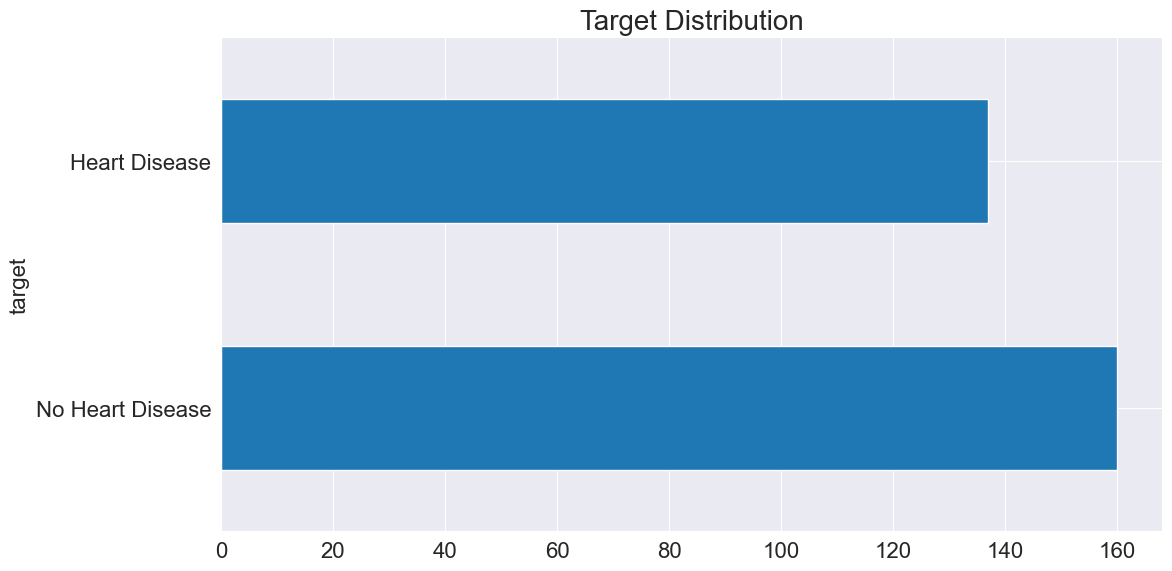

In [7]:
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(12, 6))
counter = target["target"].value_counts()
counter.rename(index={1: "Heart Disease", 0: "No Heart Disease"}, inplace=True)
ax.set_xlabel("# Cases", size=16)
ax.set_title("Target Distribution", size=20)
counter.plot(kind="barh", ax=ax)
plt.tight_layout()
plt.show()


## Recoding Original Dataset
**In order to generate the counterfactual explanations, we need the data with human-readable categorical labels instead of numeric codes.**

In [8]:
def inverse_transform(df):
    df_ = df.copy()
    df_['sex'] = df_['sex'].map({1.0: 'male', 0.0: 'female'})
    # Cleveland dataset: cp values are 1,2,3,4
    df_['cp'] = df_['cp'].map({
        1.0: 'typical angina',
        2.0: 'atypical angina',
        3.0: 'non-anginal pain',
        4.0: 'asymptomatic'
    })
    df_['fbs'] = df_['fbs'].map({1.0: 'true', 0.0: 'false'})
    df_['restecg'] = df_['restecg'].map({
        0.0: 'normal',
        1.0: 'ST-T wave abnormality',
        2.0: 'left ventricular hypertrophy'
    })
    df_['exang'] = df_['exang'].map({1.0: 'yes', 0.0: 'no'})
    # Cleveland dataset: slope values are 1,2,3
    df_['slope'] = df_['slope'].map({
        1.0: 'upsloping',
        2.0: 'flat',
        3.0: 'downsloping'
    })
    df_['thal'] = df_['thal'].map({
        3.0: 'normal',
        6.0: 'fixed defect',
        7.0: 'reversable defect'
    })
    # ca: number of major vessels (0-3)
    df_['ca'] = df_['ca'].astype(int).astype(str)
    return df_


In [9]:
features = inverse_transform(features)


In [10]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(
    features,
    target,
    test_size=0.3,
    random_state=14,
    stratify=target
)

In [11]:
x_train.head(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
65,60.0,male,asymptomatic,145.0,282.0,false,left ventricular hypertrophy,142.0,yes,2.8,flat,2,reversable defect
270,59.0,male,typical angina,134.0,204.0,false,normal,162.0,no,0.8,upsloping,2,normal
204,50.0,male,asymptomatic,144.0,200.0,false,left ventricular hypertrophy,126.0,yes,0.9,flat,0,reversable defect
232,54.0,male,asymptomatic,122.0,286.0,false,left ventricular hypertrophy,116.0,yes,3.2,flat,2,normal
152,55.0,male,asymptomatic,160.0,289.0,false,left ventricular hypertrophy,145.0,yes,0.8,flat,1,reversable defect
10,57.0,male,asymptomatic,140.0,192.0,false,normal,148.0,no,0.4,flat,0,fixed defect
238,41.0,female,atypical angina,126.0,306.0,false,normal,163.0,no,0.0,upsloping,0,normal
44,61.0,female,asymptomatic,130.0,330.0,false,left ventricular hypertrophy,169.0,no,0.0,upsloping,0,normal
253,67.0,female,asymptomatic,106.0,223.0,false,normal,142.0,no,0.3,upsloping,2,normal
45,58.0,male,non-anginal pain,112.0,230.0,false,left ventricular hypertrophy,165.0,no,2.5,flat,1,reversable defect


### Model Training



In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

In [13]:
# Categorical features (will be one-hot encoded)
categoric_features = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'thal',
    'ca'
]
# Continuous features (passed through without encoding)
numeric_features = set(features.columns) - set(categoric_features)
print("Categorical features:", categoric_features)
print("Numeric features:", numeric_features)

Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'ca']
Numeric features: {'oldpeak', 'age', 'thalach', 'chol', 'trestbps'}


**We explicitly pass the possible categories of each categorical feature to the encoder, to ensure consistency between train and test sets.**

In [14]:
# We hardcode the full list of categories for each categorical feature.
# This avoids issues with NaN or missing categories in train/test splits.
cat_types = [
    ['male', 'female'],                                                        # sex
    ['typical angina', 'atypical angina', 'non-anginal pain', 'asymptomatic'], # cp
    ['true', 'false'],                                                          # fbs
    ['normal', 'ST-T wave abnormality', 'left ventricular hypertrophy'],       # restecg
    ['yes', 'no'],                                                              # exang
    ['upsloping', 'flat', 'downsloping'],                                      # slope
    ['normal', 'fixed defect', 'reversable defect'],                           # thal
    ['0', '1', '2', '3'],                                                      # ca
]

# Drop any rows where inverse_transform produced NaN (unmapped values)
features = features.dropna(subset=categoric_features).reset_index(drop=True)
target = target.loc[features.index].reset_index(drop=True)
print('Categories OK. Dataset size after NaN drop:', len(features))


Categories OK. Dataset size after NaN drop: 297


In [15]:
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(categories=cat_types, handle_unknown='ignore'))])
preprocessor = ColumnTransformer(transformers=[('categorical', categorical_transformer, categoric_features)],
                                  remainder='passthrough')


In [16]:
params_rf = {
    "n_estimators": 100,
    "max_depth": 8,
    "random_state": 27,
}
rf = RandomForestClassifier(**params_rf)


In [17]:
# Model pipeline: preprocesses then classifies
clf_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf)
])
model = clf_rf.fit(x_train, y_train.values.ravel())
print("Model trained!")


Model trained!


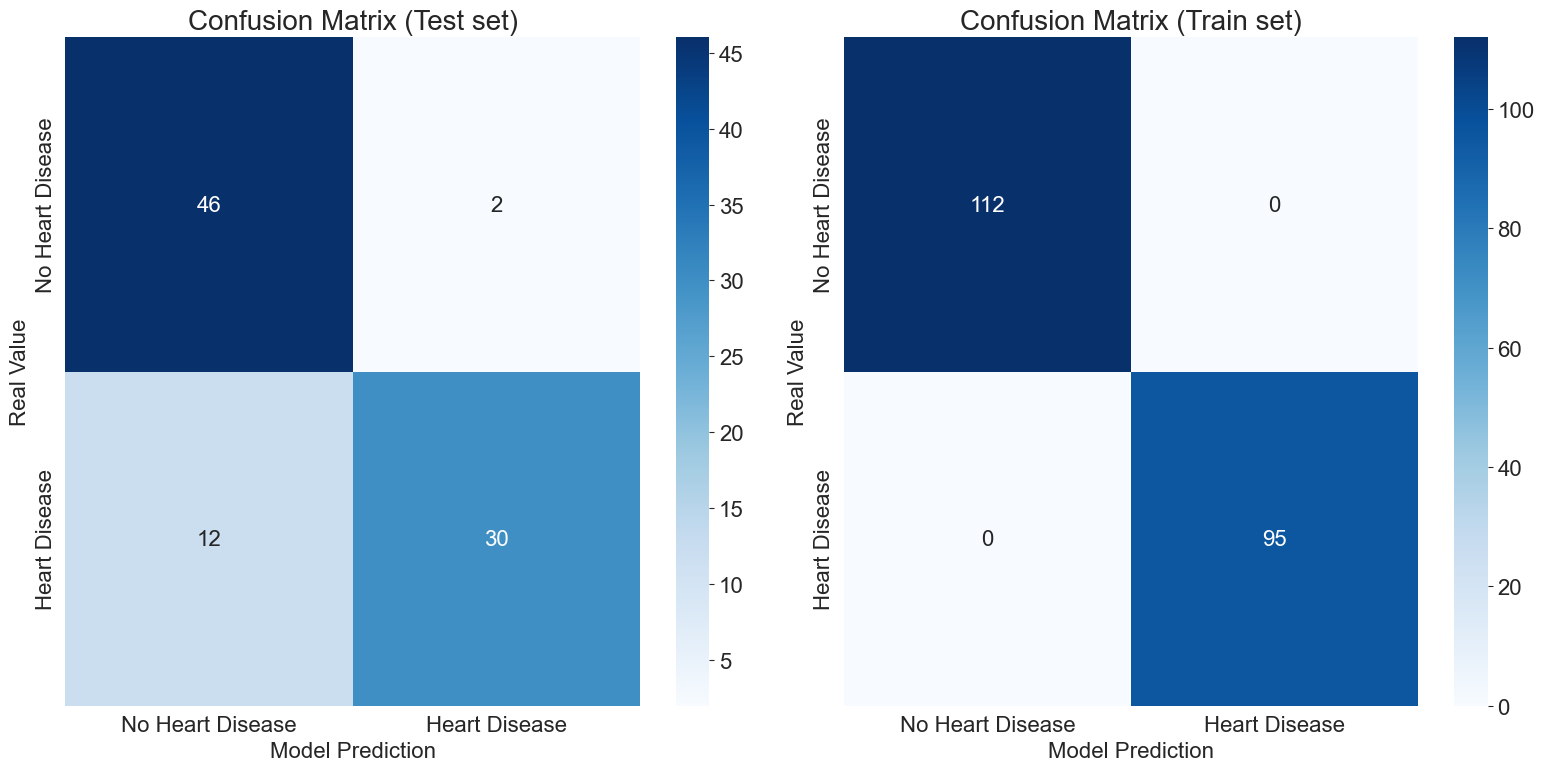

Test Accuracy: 0.844


In [18]:
y_hat = clf_rf.predict(x_test)
cf = metrics.confusion_matrix(y_pred=y_hat, y_true=y_test)
cf_train = metrics.confusion_matrix(y_pred=clf_rf.predict(x_train), y_true=y_train)

names_df = ["No Heart Disease", "Heart Disease"]
cf_df = pd.DataFrame(data=cf, columns=names_df, index=names_df)
cf_train_df = pd.DataFrame(data=cf_train, columns=names_df, index=names_df)

fig, ax = plt.subplots(ncols=2, figsize=(16, 8))

sns.heatmap(cf_df, fmt="d", annot=True, ax=ax[0], cmap='Blues')
ax[0].set_xlabel("Model Prediction", size=16)
ax[0].set_ylabel("Real Value", size=16)
ax[0].set_title("Confusion Matrix (Test set)", size=20)

sns.heatmap(cf_train_df, fmt="d", annot=True, ax=ax[1], cmap='Blues')
ax[1].set_xlabel("Model Prediction", size=16)
ax[1].set_ylabel("Real Value", size=16)
ax[1].set_title("Confusion Matrix (Train set)", size=20)

plt.tight_layout()
plt.show()

print(f"Test Accuracy: {metrics.accuracy_score(y_test, y_hat):.3f}")


### DiCE

In [19]:
# Loading the dice module
import dice_ml
from dice_ml.utils import helpers
import json


In [20]:
# DiCE data object: combine features and target into one DataFrame
X = pd.concat([features, target], axis=1)

# {1: "Heart Disease", 0: "No Heart Disease"}
data = dice_ml.Data(
    dataframe=X,
    continuous_features=list(numeric_features),
    outcome_name='target'
)

# DiCE model object
model_exp = dice_ml.Model(model=model, backend='sklearn')

# Creates the explainer
exp = dice_ml.Dice(data, model_exp, method="random")
print("DiCE explainer ready!")


DiCE explainer ready!


In [21]:
patient_index = 0

# Patient real target value
diagnosis_map = {1: "Heart Disease", 0: "No Heart Disease"}

print("-------Patient Real Diagnosis------")
print(target["target"].replace(diagnosis_map).iloc[patient_index])

print("-------Patient Predicted Diagnosis------")
patient_features = features.iloc[patient_index:patient_index+1]
pred_class = clf_rf.predict(patient_features)[0]

if pred_class == 0:
    pred_diagnosis = diagnosis_map[0]
    p1 = clf_rf.predict_proba(patient_features)[0][0]
else:
    pred_diagnosis = diagnosis_map[1]
    p1 = clf_rf.predict_proba(patient_features)[0][1]

p1_round = round(p1, 3)
print(f'Probability of being diagnosed with {pred_diagnosis}\n{p1_round}')

print("\n-------Patient Features------")
print(patient_features.to_string())


-------Patient Real Diagnosis------
No Heart Disease
-------Patient Predicted Diagnosis------
Probability of being diagnosed with No Heart Disease
0.628

-------Patient Features------
    age   sex              cp  trestbps   chol   fbs                       restecg  thalach exang  oldpeak        slope ca          thal
0  63.0  male  typical angina     145.0  233.0  true  left ventricular hypertrophy    150.0    no      2.3  downsloping  0  fixed defect


In [22]:

# We take an example from our dataset
# We set the number of counterfactual explanations to 2.
# Only actionable features are allowed to vary:
#   - age and sex are fixed (not actionable)
#   - thal and ca are fixed (not easily modifiable)
#   - restecg is fixed (diagnostic measurement, not an intervention target)
features_to_vary = [
    "cp",           # chest pain type
    "trestbps",     # resting blood pressure (modifiable with medication)
    "chol",         # cholesterol (modifiable with diet/medication)
    "fbs",          # fasting blood sugar (modifiable with diet/medication)
    "thalach",      # max heart rate (modifiable with exercise/treatment)
    "exang",        # exercise induced angina (modifiable with treatment)
    "oldpeak",      # ST depression (modifiable with treatment)
    "slope",        # slope of ST segment (modifiable with treatment)
]

e1 = exp.generate_counterfactuals(
    features.iloc[patient_index:patient_index+1],
    total_CFs=2,
    desired_class="opposite",
    random_seed=3434,
    features_to_vary=features_to_vary
)

# Show counterfactual explanations
e1.visualize_as_dataframe(show_only_changes=False)


100%|██████████| 1/1 [00:00<00:00,  7.05it/s]

Query instance (original outcome : 0)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,male,typical angina,145.0,233.0,true,left ventricular hypertrophy,150.0,no,2.3,downsloping,0,fixed defect,0



Diverse Counterfactual set (new outcome: 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,male,non-anginal pain,145.0,326.7,true,left ventricular hypertrophy,150.0,no,2.3,downsloping,0,fixed defect,1
1,63.0,male,typical angina,145.0,532.1,true,left ventricular hypertrophy,150.0,yes,2.3,downsloping,0,fixed defect,1


**The previous code can be modified to change the patient index. The counterfactual example is displayed using a dataframe showing the feature values that would need to change, according to the heart disease predictive model, in order to flip the model's output. For example, if the current patient is predicted to have heart disease, the counterfactual shows what actionable risk factor modifications (e.g., lower cholesterol, lower resting blood pressure, no exercise-induced angina) would lead the model to predict no heart disease. This provides clinically actionable insights for cardiologists.**

In [23]:
### Add Probabilities given by the model for each Counterfactual
CF_dice = e1.cf_examples_list[0].final_cfs_df
pred_cf = clf_rf.predict_proba(CF_dice.drop(columns=["target"]))
CF_dice[["No Heart Disease Prob", "Heart Disease Prob"]] = pred_cf


In [24]:
CF_dice


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,No Heart Disease Prob,Heart Disease Prob
0,63.0,male,non-anginal pain,145.0,326.7,true,left ventricular hypertrophy,150.0,no,2.3,downsloping,0,fixed defect,1,0.481571,0.518429
1,63.0,male,typical angina,145.0,532.1,true,left ventricular hypertrophy,150.0,yes,2.3,downsloping,0,fixed defect,1,0.448571,0.551429
